In [2]:
import pandas as pd
import numpy as np

In [3]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 1000)

In [4]:
main_path = "/home/sanzhar/SharuAI_Scorring_model/subsidies_merit_training_dataset.csv"
profiles_path = "/home/sanzhar/SharuAI_Scorring_model/producer_profiles_synthetic.csv"
dict_path = "/home/sanzhar/SharuAI_Scorring_model/data_dictionary_merit_dataset.csv"

df = pd.read_csv(main_path)
profiles_df = pd.read_csv(profiles_path)
data_dict_df = pd.read_csv(dict_path)

In [5]:
print("Основной датасет:", df.shape)
print("Профили хозяйств:", profiles_df.shape)
print("Словарь полей:", data_dict_df.shape)

Основной датасет: (36651, 61)
Профили хозяйств: (12108, 35)
Словарь полей: (61, 4)


In [6]:
df.head()

,record_no,application_id,application_received_at,application_date,year,month,quarter,day_of_year,application_hour,region,district,akimat,direction,species,subsidy_program,application_status,normative_kzt_per_unit,entitled_amount_kzt,subsidized_units_est,producer_id,producer_type,years_in_operation,employees_count,land_area_ha,herd_size_head,output_volume_tons,productivity_index,revenue_kzt,ebitda_margin_pct,debt_to_revenue_pct,prior_subsidies_count_3y,prior_subsidies_amount_kzt_3y,prior_violations_count_3y,prior_refunds_count_3y,prior_refunds_amount_kzt_3y,unmet_obligations_flag,prior_avg_output_growth_pct,prior_avg_revenue_growth_pct,producer_application_seq_no,past_applications_count,past_approved_count,past_rejected_count,past_withdrawn_count,past_paid_amount_kzt,past_avg_entitled_amount_kzt,region_execution_rate_real,district_execution_rate_real,direction_execution_rate_real,program_execution_rate_real,need_score,impact_score,compliance_score,merit_score,shortlist_bucket,merit_recommended_flag,post_effect_output_growth_pct,post_effect_revenue_growth_pct,post_effect_productivity_growth_pct,post_effect_compliance_flag,outcome_effective_flag,data_origin
0,90553.0,1101100386823,2025-12-19 15:34:33,2025-12-19,2025,12,4,353,15,Акмолинская область,unknown,"ГУ ""Управление сельского хозяйства и земельных...",Субсидирование затрат по искусственному осемен...,insemination,Заявка на получение субсидий племенным и дистр...,Одобрена,5000.0,2540000.0,508.0,PRD_000001,llp,7,18,1761.9,487,876.1,125.1,8.499157e+08,0.2430,0.6628,2,6651361.0,1,0,0.0,0,0.1210,0.0582,1,0,0,0,0,0.0,0.0,0.8027,1.000000,0.838057,0.860465,41.5,60.7,77.9,59.2,low_priority,0,0.0967,0.2020,0.1038,1,1,real_base+synthetic_enrichment
1,67737.0,700100299293,2025-05-06 22:14:07,2025-05-06,2025,5,2,126,22,Акмолинская область,Аккольский район,"ГУ ""Управление сельского хозяйства и земельных...",Субсидирование в скотоводстве,cattle,Заявка на получение субсидий за приобретение п...,Сформировано поручение,150000.0,750000.0,5.0,PRD_000002,llp,17,2,222.9,45,91.9,116.6,8.039290e+07,0.3267,0.5355,6,750000.0,0,0,0.0,0,0.1621,0.1931,1,0,0,0,0,0.0,2540000.0,0.8027,0.770833,0.867238,0.852097,55.1,55.8,88.0,67.9,committee_review,0,0.1842,0.1513,0.1399,1,1,real_base+synthetic_enrichment
2,61188.0,1900100270358,2025-03-06 14:22:49,2025-03-06,2025,3,1,65,14,Акмолинская область,Аккольский район,"ГУ ""Управление сельского хозяйства и земельных...",Субсидирование в скотоводстве,cattle,Заявка на получение субсидий на удешевление ст...,Исполнена,20.0,1018760.0,50938.0,PRD_000004,llp,14,1500,408603.7,81466,147551.2,101.7,1.404313e+11,0.2751,0.5027,7,6101067.0,0,0,0.0,0,0.1154,0.2136,1,0,0,0,0,0.0,750000.0,0.8027,0.770833,0.867238,0.838642,36.5,52.6,89.5,51.1,low_priority,0,0.1294,0.1306,0.1643,1,1,real_base+synthetic_enrichment
3,71226.0,1700100315547,2025-06-02 21:37:32,2025-06-02,2025,6,2,153,21,Акмолинская область,Аккольский район,"ГУ ""Управление сельского хозяйства и земельных...",Субсидирование в скотоводстве,cattle,Заявка на получение субсидий на удешевление ст...,Сформировано поручение,45.0,682020.0,15156.0,PRD_000004,llp,14,1500,408603.7,81466,147551.2,101.7,1.404313e+11,0.2751,0.5027,7,6101067.0,0,0,0.0,0,0.1154,0.2136,2,1,1,0,0,1018760.0,1018760.0,0.8027,0.770833,0.867238,0.899120,41.4,56.2,88.0,59.3,low_priority,0,0.1536,0.1437,0.1626,1,1,real_base+synthetic_enrichment
4,89137.0,1900100382341,2025-12-11 12:26:34,2025-12-11,2025,12,4,345,12,Акмолинская область,Аккольский район,"ГУ ""Управление сельского хозяйства и земельных...",Субсидирование в скотоводстве,cattle,Заявка на получение субсидий на удешевление ст...,Одобрена,20.0,1104160.0,55208.0,PRD_000004,llp,14,1500,408603.7,81466,147551.2,101.7,1.404313e+11,0.2751,0.5027,7,6101067.0,0,0,0.0,0,0.1154,0.2136,3,2,2,0,0,1700780.0,850390.0,0.8027,0.770833,0.867238,0.838642,33.9,56.6,87.2,54.5,low_priority,0,0.1340,0.1669,0.1414,1,1,real_base+synthetic_enrichment


In [7]:
profiles_df.head()

,producer_id,region,district,main_direction,main_species,main_program,producer_type,years_in_operation,employees_count,land_area_ha,herd_size_head,output_volume_tons,productivity_index,revenue_kzt,ebitda_margin_pct,debt_to_revenue_pct,prior_subsidies_count_3y,prior_subsidies_amount_kzt_3y,prior_violations_count_3y,prior_refunds_count_3y,prior_refunds_amount_kzt_3y,unmet_obligations_flag,prior_avg_output_growth_pct,prior_avg_revenue_growth_pct,revenue_kzt_pct,prior_subsidies_amount_kzt_3y_pct,productivity_index_pct,output_volume_tons_pct,debt_to_revenue_pct_pct,ebitda_margin_pct_pct,need_score_base,impact_score_base,compliance_score_base,merit_score_base,shortlist_bucket_base
0,PRD_000001,Акмолинская область,unknown,Субсидирование затрат по искусственному осемен...,insemination,Заявка на получение субсидий племенным и дистр...,llp,7,18,1761.9,487,876.1,125.1,8.499157e+08,0.2430,0.6628,2,6651361.0,1,0,0.0,0,0.1210,0.0582,0.580112,0.580443,0.927032,0.576148,0.727618,0.334118,49.2,58.9,86.9,66.7,committee_review
1,PRD_000002,Акмолинская область,Аккольский район,Субсидирование в скотоводстве,cattle,Заявка на получение субсидий за приобретение п...,llp,17,2,222.9,45,91.9,116.6,8.039290e+07,0.3267,0.5355,6,750000.0,0,0,0.0,0,0.1621,0.1931,0.176412,0.144367,0.710852,0.203461,0.234349,0.942765,68.6,51.7,100.0,77.5,priority_shortlist
2,PRD_000004,Акмолинская область,Аккольский район,Субсидирование в скотоводстве,cattle,Заявка на получение субсидий на удешевление ст...,llp,14,1500,408603.7,81466,147551.2,101.7,1.404313e+11,0.2751,0.5027,7,6101067.0,0,0,0.0,0,0.1154,0.2136,0.859927,0.559382,0.223943,0.859101,0.134746,0.602577,36.3,48.0,100.0,52.8,low_priority
3,PRD_000005,Акмолинская область,Аккольский район,Субсидирование в скотоводстве,cattle,Заявка на получение субсидий на удешевление ст...,llp,12,1500,324995.7,76416,163377.5,104.5,1.157502e+11,0.2513,0.7164,6,2636285.0,5,3,109586.0,1,-0.0529,0.0092,0.851833,0.360258,0.290758,0.863396,0.860877,0.394904,45.0,37.0,0.0,19.6,low_priority
4,PRD_000006,Акмолинская область,Аккольский район,Субсидирование в скотоводстве,cattle,Заявка на получение субсидий на удешевление ст...,llp,14,1500,461668.7,112249,163301.6,84.4,1.425211e+11,0.1854,0.6780,5,2580306.0,2,2,35749.0,1,0.0482,0.1026,0.860505,0.356376,0.052651,0.863314,0.772010,0.103609,44.7,35.7,36.6,26.4,low_priority


In [8]:
data_dict_df.head(10)

,column_name,source_type,role,description_ru
0,record_no,real_or_derived_from_uploaded_file,id,Реальный номер строки из выгрузки
1,application_id,real_or_derived_from_uploaded_file,id,Реальный номер заявки из выгрузки
2,application_received_at,real_or_derived_from_uploaded_file,feature,Реальная дата/время поступления заявки
3,application_date,derived_from_uploaded_file,feature,Дата заявки (derived)
4,year,derived_from_uploaded_file,feature,Год из даты заявки (derived)
5,month,derived_from_uploaded_file,feature,Месяц из даты заявки (derived)
6,quarter,derived_from_uploaded_file,feature,Квартал из даты заявки (derived)
7,day_of_year,derived_from_uploaded_file,feature,Порядковый день года (derived)
8,application_hour,derived_from_uploaded_file,feature,Час подачи заявки (derived)
9,region,real_or_derived_from_uploaded_file,feature,Реальная область


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 36651 entries, 0 to 36650
Data columns (total 61 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   record_no                            36651 non-null  float64
 1   application_id                       36651 non-null  int64  
 2   application_received_at              36651 non-null  str    
 3   application_date                     36651 non-null  str    
 4   year                                 36651 non-null  int64  
 5   month                                36651 non-null  int64  
 6   quarter                              36651 non-null  int64  
 7   day_of_year                          36651 non-null  int64  
 8   application_hour                     36651 non-null  int64  
 9   region                               36651 non-null  str    
 10  district                             36651 non-null  str    
 11  akimat                               36

In [10]:
profiles_df.columns.tolist()

['producer_id',
 'region',
 'district',
 'main_direction',
 'main_species',
 'main_program',
 'producer_type',
 'years_in_operation',
 'employees_count',
 'land_area_ha',
 'herd_size_head',
 'output_volume_tons',
 'productivity_index',
 'revenue_kzt',
 'ebitda_margin_pct',
 'debt_to_revenue_pct',
 'prior_subsidies_count_3y',
 'prior_subsidies_amount_kzt_3y',
 'prior_violations_count_3y',
 'prior_refunds_count_3y',
 'prior_refunds_amount_kzt_3y',
 'unmet_obligations_flag',
 'prior_avg_output_growth_pct',
 'prior_avg_revenue_growth_pct',
 'revenue_kzt_pct',
 'prior_subsidies_amount_kzt_3y_pct',
 'productivity_index_pct',
 'output_volume_tons_pct',
 'debt_to_revenue_pct_pct',
 'ebitda_margin_pct_pct',
 'need_score_base',
 'impact_score_base',
 'compliance_score_base',
 'merit_score_base',
 'shortlist_bucket_base']

In [11]:
missing_df = pd.DataFrame({
    "column": df.columns,
    "missing_count": df.isnull().sum().values,
    "missing_pct": (df.isnull().mean().values * 100).round(2)
}).sort_values("missing_pct", ascending=False)

missing_df.head(20)

,column,missing_count,missing_pct
0,record_no,0,0.0
1,application_id,0,0.0
2,application_received_at,0,0.0
3,application_date,0,0.0
4,year,0,0.0
5,month,0,0.0
6,quarter,0,0.0
7,day_of_year,0,0.0
8,application_hour,0,0.0
9,region,0,0.0


In [12]:
[target for target in df.columns if "score" in target.lower() or "effect" in target.lower()]

['need_score',
 'impact_score',
 'compliance_score',
 'merit_score',
 'post_effect_output_growth_pct',
 'post_effect_revenue_growth_pct',
 'post_effect_productivity_growth_pct',
 'post_effect_compliance_flag',
 'outcome_effective_flag']

In [13]:
target_col = "merit_score"

print("Есть ли target в таблице:", target_col in df.columns)

if target_col in df.columns:
    display(df[target_col].head())
    display(df[target_col].describe())

Есть ли target в таблице: True


0    59.2
1    67.9
2    51.1
3    59.3
4    54.5
Name: merit_score, dtype: float64

count    36651.000000
mean        55.245868
std         15.546519
min         15.400000
25%         43.200000
50%         56.100000
75%         68.300000
max         84.200000
Name: merit_score, dtype: float64

In [14]:
leakage_cols = [col for col in df.columns if "score" in col.lower() or "effect" in col.lower()]
leakage_cols = [col for col in leakage_cols if col != target_col]
print("Потенциальные признаки утечки:", leakage_cols)


Потенциальные признаки утечки: ['need_score', 'impact_score', 'compliance_score', 'post_effect_output_growth_pct', 'post_effect_revenue_growth_pct', 'post_effect_productivity_growth_pct', 'post_effect_compliance_flag', 'outcome_effective_flag']


In [15]:
drop_cols = leakage_cols
print("Признаки для удаления из-за утечки:", drop_cols)


Признаки для удаления из-за утечки: ['need_score', 'impact_score', 'compliance_score', 'post_effect_output_growth_pct', 'post_effect_revenue_growth_pct', 'post_effect_productivity_growth_pct', 'post_effect_compliance_flag', 'outcome_effective_flag']


In [16]:
id_cols = [col for col in df.columns if "id" in col.lower()]
print("Потенциальные идентификаторы:", id_cols)

Потенциальные идентификаторы: ['application_id', 'subsidy_program', 'subsidized_units_est', 'producer_id', 'prior_subsidies_count_3y', 'prior_subsidies_amount_kzt_3y', 'past_paid_amount_kzt']


In [17]:
drop_cols += id_cols
print("Все признаки для удаления:", drop_cols)

Все признаки для удаления: ['need_score', 'impact_score', 'compliance_score', 'post_effect_output_growth_pct', 'post_effect_revenue_growth_pct', 'post_effect_productivity_growth_pct', 'post_effect_compliance_flag', 'outcome_effective_flag', 'application_id', 'subsidy_program', 'subsidized_units_est', 'producer_id', 'prior_subsidies_count_3y', 'prior_subsidies_amount_kzt_3y', 'past_paid_amount_kzt']


In [18]:
target_col = "merit_score"

true_id_cols = ["application_id", "producer_id"]

leakage_cols = [
    "impact_score",
    "need_score",
    "compliance_score",
    "outcome_effective_flag",
    "post_effect_compliance_flag",
    "post_effect_output_growth_pct",
    "post_effect_productivity_growth_pct",
    "post_effect_revenue_growth_pct",
]

drop_cols = sorted(set([target_col] + true_id_cols + leakage_cols))

print("Колонки на удаление:", drop_cols)
print("Количество:", len(drop_cols))

Колонки на удаление: ['application_id', 'compliance_score', 'impact_score', 'merit_score', 'need_score', 'outcome_effective_flag', 'post_effect_compliance_flag', 'post_effect_output_growth_pct', 'post_effect_productivity_growth_pct', 'post_effect_revenue_growth_pct', 'producer_id']
Количество: 11


In [19]:
all_cols = df.columns.tolist()
all_cols

['record_no',
 'application_id',
 'application_received_at',
 'application_date',
 'year',
 'month',
 'quarter',
 'day_of_year',
 'application_hour',
 'region',
 'district',
 'akimat',
 'direction',
 'species',
 'subsidy_program',
 'application_status',
 'normative_kzt_per_unit',
 'entitled_amount_kzt',
 'subsidized_units_est',
 'producer_id',
 'producer_type',
 'years_in_operation',
 'employees_count',
 'land_area_ha',
 'herd_size_head',
 'output_volume_tons',
 'productivity_index',
 'revenue_kzt',
 'ebitda_margin_pct',
 'debt_to_revenue_pct',
 'prior_subsidies_count_3y',
 'prior_subsidies_amount_kzt_3y',
 'prior_violations_count_3y',
 'prior_refunds_count_3y',
 'prior_refunds_amount_kzt_3y',
 'unmet_obligations_flag',
 'prior_avg_output_growth_pct',
 'prior_avg_revenue_growth_pct',
 'producer_application_seq_no',
 'past_applications_count',
 'past_approved_count',
 'past_rejected_count',
 'past_withdrawn_count',
 'past_paid_amount_kzt',
 'past_avg_entitled_amount_kzt',
 'region_execu

In [20]:
suspicious_keywords = [
    "score",
    "post",
    "effect",
    "outcome",
    "result",
    "final",
    "approved",
    "rejected",
    "executed",
    "paid",
    "payment",
    "decision",
    "recommend",
    "shortlist",
    "compliance",
    "violation",
    "return",
    "default",
    "target",
    "label"
]

suspicious_cols = sorted([
    col for col in df.columns
    if any(keyword in col.lower() for keyword in suspicious_keywords)
])

print("Подозрительные колонки:")
print(suspicious_cols)
print("Количество:", len(suspicious_cols))

Подозрительные колонки:
['compliance_score', 'impact_score', 'merit_recommended_flag', 'merit_score', 'need_score', 'outcome_effective_flag', 'past_approved_count', 'past_paid_amount_kzt', 'past_rejected_count', 'post_effect_compliance_flag', 'post_effect_output_growth_pct', 'post_effect_productivity_growth_pct', 'post_effect_revenue_growth_pct', 'prior_violations_count_3y', 'shortlist_bucket']
Количество: 15


In [21]:
import re

id_like_cols = sorted([
    col for col in df.columns
    if re.search(r'(^id$|^id_|_id$|identifier|application_id|producer_id)', col.lower())
])

print("Колонки, похожие на настоящие ID:")
print(id_like_cols)

Колонки, похожие на настоящие ID:
['application_id', 'producer_id']


In [22]:
post_fact_cols = sorted([
    col for col in df.columns
    if any(keyword in col.lower() for keyword in [
        "post_",
        "outcome",
        "effect",
        "growth",
        "after",
        "effective_flag"
    ])
])

print("Пост-фактум колонки:")
print(post_fact_cols)

Пост-фактум колонки:
['outcome_effective_flag', 'post_effect_compliance_flag', 'post_effect_output_growth_pct', 'post_effect_productivity_growth_pct', 'post_effect_revenue_growth_pct', 'prior_avg_output_growth_pct', 'prior_avg_revenue_growth_pct']


In [23]:
decision_cols = sorted([
    col for col in df.columns
    if any(keyword in col.lower() for keyword in [
        "status",
        "approved",
        "rejected",
        "decision",
        "executed",
        "paid",
        "payment",
        "shortlist",
        "recommended"
    ])
])

print("Колонки, похожие на решение/статус:")
print(decision_cols)

Колонки, похожие на решение/статус:
['application_status', 'merit_recommended_flag', 'past_approved_count', 'past_paid_amount_kzt', 'past_rejected_count', 'shortlist_bucket']


In [24]:
target_col = "merit_score"

drop_cols = [
    "application_id",
    "producer_id",
    "merit_score",
    "impact_score",
    "need_score",
    "compliance_score",
    "application_status",
    "merit_recommended_flag",
    "shortlist_bucket",
    "outcome_effective_flag",
    "post_effect_compliance_flag",
    "post_effect_output_growth_pct",
    "post_effect_productivity_growth_pct",
    "post_effect_revenue_growth_pct",
]

drop_cols = sorted(set(drop_cols))

print("Колонки на удаление:")
print(drop_cols)
print("Количество:", len(drop_cols))

Колонки на удаление:
['application_id', 'application_status', 'compliance_score', 'impact_score', 'merit_recommended_flag', 'merit_score', 'need_score', 'outcome_effective_flag', 'post_effect_compliance_flag', 'post_effect_output_growth_pct', 'post_effect_productivity_growth_pct', 'post_effect_revenue_growth_pct', 'producer_id', 'shortlist_bucket']
Количество: 14


In [25]:
group_col = df["producer_id"].copy()

feature_cols = [col for col in df.columns if col not in drop_cols]

X = df[feature_cols].copy()
y = df[target_col].copy()

print("Размер X:", X.shape)
print("Размер y:", y.shape)
print("Количество признаков:", len(feature_cols))

Размер X: (36651, 47)
Размер y: (36651,)
Количество признаков: 47


In [26]:
important_history_cols = [
    "past_approved_count",
    "past_rejected_count",
    "past_paid_amount_kzt",
    "prior_violations_count_3y",
    "prior_avg_output_growth_pct",
    "prior_avg_revenue_growth_pct",
]

for col in important_history_cols:
    print(col, "->", col in X.columns)

past_approved_count -> True
past_rejected_count -> True
past_paid_amount_kzt -> True
prior_violations_count_3y -> True
prior_avg_output_growth_pct -> True
prior_avg_revenue_growth_pct -> True


In [27]:
numeric_cols = X.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Числовые признаки:", len(numeric_cols))
print(numeric_cols)

print("\nКатегориальные признаки:", len(categorical_cols))
print(categorical_cols)

Числовые признаки: 37
['record_no', 'year', 'month', 'quarter', 'day_of_year', 'application_hour', 'normative_kzt_per_unit', 'entitled_amount_kzt', 'subsidized_units_est', 'years_in_operation', 'employees_count', 'land_area_ha', 'herd_size_head', 'output_volume_tons', 'productivity_index', 'revenue_kzt', 'ebitda_margin_pct', 'debt_to_revenue_pct', 'prior_subsidies_count_3y', 'prior_subsidies_amount_kzt_3y', 'prior_violations_count_3y', 'prior_refunds_count_3y', 'prior_refunds_amount_kzt_3y', 'unmet_obligations_flag', 'prior_avg_output_growth_pct', 'prior_avg_revenue_growth_pct', 'producer_application_seq_no', 'past_applications_count', 'past_approved_count', 'past_rejected_count', 'past_withdrawn_count', 'past_paid_amount_kzt', 'past_avg_entitled_amount_kzt', 'region_execution_rate_real', 'district_execution_rate_real', 'direction_execution_rate_real', 'program_execution_rate_real']

Категориальные признаки: 10
['application_received_at', 'application_date', 'region', 'district', 'akim

/tmp/ipykernel_8581/2086469413.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()


In [28]:
date_candidate_cols = ["application_received_at", "application_date"]

for col in date_candidate_cols:
    if col in X.columns:
        X[col] = pd.to_datetime(X[col], errors="coerce")

X[date_candidate_cols].head()

,application_received_at,application_date
0,2025-12-19 15:34:33,2025-12-19
1,2025-05-06 22:14:07,2025-05-06
2,2025-03-06 14:22:49,2025-03-06
3,2025-06-02 21:37:32,2025-06-02
4,2025-12-11 12:26:34,2025-12-11


In [29]:
if "application_received_at" in X.columns:
    X["received_dayofweek"] = X["application_received_at"].dt.dayofweek
    X["received_is_weekend"] = X["application_received_at"].dt.dayofweek.isin([5, 6]).astype(int)
    X["received_day"] = X["application_received_at"].dt.day
    X["received_week"] = X["application_received_at"].dt.isocalendar().week.astype("float")

if "application_date" in X.columns:
    X["app_dayofweek"] = X["application_date"].dt.dayofweek
    X["app_is_month_start"] = X["application_date"].dt.is_month_start.astype(int)
    X["app_is_month_end"] = X["application_date"].dt.is_month_end.astype(int)

X.head()

,record_no,application_received_at,application_date,year,month,quarter,day_of_year,application_hour,region,district,akimat,direction,species,subsidy_program,normative_kzt_per_unit,entitled_amount_kzt,subsidized_units_est,producer_type,years_in_operation,employees_count,land_area_ha,herd_size_head,output_volume_tons,productivity_index,revenue_kzt,ebitda_margin_pct,debt_to_revenue_pct,prior_subsidies_count_3y,prior_subsidies_amount_kzt_3y,prior_violations_count_3y,prior_refunds_count_3y,prior_refunds_amount_kzt_3y,unmet_obligations_flag,prior_avg_output_growth_pct,prior_avg_revenue_growth_pct,producer_application_seq_no,past_applications_count,past_approved_count,past_rejected_count,past_withdrawn_count,past_paid_amount_kzt,past_avg_entitled_amount_kzt,region_execution_rate_real,district_execution_rate_real,direction_execution_rate_real,program_execution_rate_real,data_origin,received_dayofweek,received_is_weekend,received_day,received_week,app_dayofweek,app_is_month_start,app_is_month_end
0,90553.0,2025-12-19 15:34:33,2025-12-19,2025,12,4,353,15,Акмолинская область,unknown,"ГУ ""Управление сельского хозяйства и земельных...",Субсидирование затрат по искусственному осемен...,insemination,Заявка на получение субсидий племенным и дистр...,5000.0,2540000.0,508.0,llp,7,18,1761.9,487,876.1,125.1,8.499157e+08,0.2430,0.6628,2,6651361.0,1,0,0.0,0,0.1210,0.0582,1,0,0,0,0,0.0,0.0,0.8027,1.000000,0.838057,0.860465,real_base+synthetic_enrichment,4,0,19,51.0,4,0,0
1,67737.0,2025-05-06 22:14:07,2025-05-06,2025,5,2,126,22,Акмолинская область,Аккольский район,"ГУ ""Управление сельского хозяйства и земельных...",Субсидирование в скотоводстве,cattle,Заявка на получение субсидий за приобретение п...,150000.0,750000.0,5.0,llp,17,2,222.9,45,91.9,116.6,8.039290e+07,0.3267,0.5355,6,750000.0,0,0,0.0,0,0.1621,0.1931,1,0,0,0,0,0.0,2540000.0,0.8027,0.770833,0.867238,0.852097,real_base+synthetic_enrichment,1,0,6,19.0,1,0,0
2,61188.0,2025-03-06 14:22:49,2025-03-06,2025,3,1,65,14,Акмолинская область,Аккольский район,"ГУ ""Управление сельского хозяйства и земельных...",Субсидирование в скотоводстве,cattle,Заявка на получение субсидий на удешевление ст...,20.0,1018760.0,50938.0,llp,14,1500,408603.7,81466,147551.2,101.7,1.404313e+11,0.2751,0.5027,7,6101067.0,0,0,0.0,0,0.1154,0.2136,1,0,0,0,0,0.0,750000.0,0.8027,0.770833,0.867238,0.838642,real_base+synthetic_enrichment,3,0,6,10.0,3,0,0
3,71226.0,2025-06-02 21:37:32,2025-06-02,2025,6,2,153,21,Акмолинская область,Аккольский район,"ГУ ""Управление сельского хозяйства и земельных...",Субсидирование в скотоводстве,cattle,Заявка на получение субсидий на удешевление ст...,45.0,682020.0,15156.0,llp,14,1500,408603.7,81466,147551.2,101.7,1.404313e+11,0.2751,0.5027,7,6101067.0,0,0,0.0,0,0.1154,0.2136,2,1,1,0,0,1018760.0,1018760.0,0.8027,0.770833,0.867238,0.899120,real_base+synthetic_enrichment,0,0,2,23.0,0,0,0
4,89137.0,2025-12-11 12:26:34,2025-12-11,2025,12,4,345,12,Акмолинская область,Аккольский район,"ГУ ""Управление сельского хозяйства и земельных...",Субсидирование в скотоводстве,cattle,Заявка на получение субсидий на удешевление ст...,20.0,1104160.0,55208.0,llp,14,1500,408603.7,81466,147551.2,101.7,1.404313e+11,0.2751,0.5027,7,6101067.0,0,0,0.0,0,0.1154,0.2136,3,2,2,0,0,1700780.0,850390.0,0.8027,0.770833,0.867238,0.838642,real_base+synthetic_enrichment,3,0,11,50.0,3,0,0


In [30]:
raw_date_cols = ["application_received_at", "application_date"]
raw_date_cols = [col for col in raw_date_cols if col in X.columns]

X = X.drop(columns=raw_date_cols)

print("После удаления сырых дат X:", X.shape)

После удаления сырых дат X: (36651, 52)


In [31]:
numeric_cols = X.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object", "category", "bool", "string"]).columns.tolist()

print("Числовые признаки:", len(numeric_cols))
print(numeric_cols)

print("\nКатегориальные признаки:", len(categorical_cols))
print(categorical_cols)

Числовые признаки: 44
['record_no', 'year', 'month', 'quarter', 'day_of_year', 'application_hour', 'normative_kzt_per_unit', 'entitled_amount_kzt', 'subsidized_units_est', 'years_in_operation', 'employees_count', 'land_area_ha', 'herd_size_head', 'output_volume_tons', 'productivity_index', 'revenue_kzt', 'ebitda_margin_pct', 'debt_to_revenue_pct', 'prior_subsidies_count_3y', 'prior_subsidies_amount_kzt_3y', 'prior_violations_count_3y', 'prior_refunds_count_3y', 'prior_refunds_amount_kzt_3y', 'unmet_obligations_flag', 'prior_avg_output_growth_pct', 'prior_avg_revenue_growth_pct', 'producer_application_seq_no', 'past_applications_count', 'past_approved_count', 'past_rejected_count', 'past_withdrawn_count', 'past_paid_amount_kzt', 'past_avg_entitled_amount_kzt', 'region_execution_rate_real', 'district_execution_rate_real', 'direction_execution_rate_real', 'program_execution_rate_real', 'received_dayofweek', 'received_is_weekend', 'received_day', 'received_week', 'app_dayofweek', 'app_is_m

In [32]:
print("Пропусков в y:", y.isnull().sum())

Пропусков в y: 0


In [33]:
mask = y.notnull()

X = X[mask].copy()
y = y[mask].copy()
group_col = group_col[mask].copy()

print(X.shape, y.shape, group_col.shape)

(36651, 52) (36651,) (36651,)


In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [35]:
eda_df = df.copy()

date_cols = ["application_received_at", "application_date"]

for col in date_cols:
    if col in eda_df.columns:
        eda_df[col] = pd.to_datetime(eda_df[col], errors="coerce")

print(eda_df.shape)
eda_df.head()

(36651, 61)


,record_no,application_id,application_received_at,application_date,year,month,quarter,day_of_year,application_hour,region,district,akimat,direction,species,subsidy_program,application_status,normative_kzt_per_unit,entitled_amount_kzt,subsidized_units_est,producer_id,producer_type,years_in_operation,employees_count,land_area_ha,herd_size_head,output_volume_tons,productivity_index,revenue_kzt,ebitda_margin_pct,debt_to_revenue_pct,prior_subsidies_count_3y,prior_subsidies_amount_kzt_3y,prior_violations_count_3y,prior_refunds_count_3y,prior_refunds_amount_kzt_3y,unmet_obligations_flag,prior_avg_output_growth_pct,prior_avg_revenue_growth_pct,producer_application_seq_no,past_applications_count,past_approved_count,past_rejected_count,past_withdrawn_count,past_paid_amount_kzt,past_avg_entitled_amount_kzt,region_execution_rate_real,district_execution_rate_real,direction_execution_rate_real,program_execution_rate_real,need_score,impact_score,compliance_score,merit_score,shortlist_bucket,merit_recommended_flag,post_effect_output_growth_pct,post_effect_revenue_growth_pct,post_effect_productivity_growth_pct,post_effect_compliance_flag,outcome_effective_flag,data_origin
0,90553.0,1101100386823,2025-12-19 15:34:33,2025-12-19,2025,12,4,353,15,Акмолинская область,unknown,"ГУ ""Управление сельского хозяйства и земельных...",Субсидирование затрат по искусственному осемен...,insemination,Заявка на получение субсидий племенным и дистр...,Одобрена,5000.0,2540000.0,508.0,PRD_000001,llp,7,18,1761.9,487,876.1,125.1,8.499157e+08,0.2430,0.6628,2,6651361.0,1,0,0.0,0,0.1210,0.0582,1,0,0,0,0,0.0,0.0,0.8027,1.000000,0.838057,0.860465,41.5,60.7,77.9,59.2,low_priority,0,0.0967,0.2020,0.1038,1,1,real_base+synthetic_enrichment
1,67737.0,700100299293,2025-05-06 22:14:07,2025-05-06,2025,5,2,126,22,Акмолинская область,Аккольский район,"ГУ ""Управление сельского хозяйства и земельных...",Субсидирование в скотоводстве,cattle,Заявка на получение субсидий за приобретение п...,Сформировано поручение,150000.0,750000.0,5.0,PRD_000002,llp,17,2,222.9,45,91.9,116.6,8.039290e+07,0.3267,0.5355,6,750000.0,0,0,0.0,0,0.1621,0.1931,1,0,0,0,0,0.0,2540000.0,0.8027,0.770833,0.867238,0.852097,55.1,55.8,88.0,67.9,committee_review,0,0.1842,0.1513,0.1399,1,1,real_base+synthetic_enrichment
2,61188.0,1900100270358,2025-03-06 14:22:49,2025-03-06,2025,3,1,65,14,Акмолинская область,Аккольский район,"ГУ ""Управление сельского хозяйства и земельных...",Субсидирование в скотоводстве,cattle,Заявка на получение субсидий на удешевление ст...,Исполнена,20.0,1018760.0,50938.0,PRD_000004,llp,14,1500,408603.7,81466,147551.2,101.7,1.404313e+11,0.2751,0.5027,7,6101067.0,0,0,0.0,0,0.1154,0.2136,1,0,0,0,0,0.0,750000.0,0.8027,0.770833,0.867238,0.838642,36.5,52.6,89.5,51.1,low_priority,0,0.1294,0.1306,0.1643,1,1,real_base+synthetic_enrichment
3,71226.0,1700100315547,2025-06-02 21:37:32,2025-06-02,2025,6,2,153,21,Акмолинская область,Аккольский район,"ГУ ""Управление сельского хозяйства и земельных...",Субсидирование в скотоводстве,cattle,Заявка на получение субсидий на удешевление ст...,Сформировано поручение,45.0,682020.0,15156.0,PRD_000004,llp,14,1500,408603.7,81466,147551.2,101.7,1.404313e+11,0.2751,0.5027,7,6101067.0,0,0,0.0,0,0.1154,0.2136,2,1,1,0,0,1018760.0,1018760.0,0.8027,0.770833,0.867238,0.899120,41.4,56.2,88.0,59.3,low_priority,0,0.1536,0.1437,0.1626,1,1,real_base+synthetic_enrichment
4,89137.0,1900100382341,2025-12-11 12:26:34,2025-12-11,2025,12,4,345,12,Акмолинская область,Аккольский район,"ГУ ""Управление сельского хозяйства и земельных...",Субсидирование в скотоводстве,cattle,Заявка на получение субсидий на удешевление ст...,Одобрена,20.0,1104160.0,55208.0,PRD_000004,llp,14,1500,408603.7,81466,147551.2,101.7,1.404313e+11,0.2751,0.5027,7,6101067.0,0,0,0.0,0,0.1154,0.2136,3,2,2,0,0,1700780.0,850390.0,0.8027,0.770833,0.867238,0.838642,33.9,56.6,87.2,54.5,low_priority,0,0.1340,0.1669,0.1414,1,1,real_base+synthetic_enrichment


In [36]:
print("Количество строк и колонок:", eda_df.shape)
print("\nТипы данных:")
display(eda_df.dtypes.value_counts())

print("\nПропуски по всему датасету:")
print("Всего пропусков:", eda_df.isnull().sum().sum())
print("Доля пропусков:", round(eda_df.isnull().sum().sum() / (eda_df.shape[0] * eda_df.shape[1]) * 100, 2), "%")

Количество строк и колонок: (36651, 61)

Типы данных:


float64           27
int64             21
str               11
datetime64[us]     2
Name: count, dtype: int64


Пропуски по всему датасету:
Всего пропусков: 0
Доля пропусков: 0.0 %


In [37]:
eda_df["merit_score"].describe()

count    36651.000000
mean        55.245868
std         15.546519
min         15.400000
25%         43.200000
50%         56.100000
75%         68.300000
max         84.200000
Name: merit_score, dtype: float64

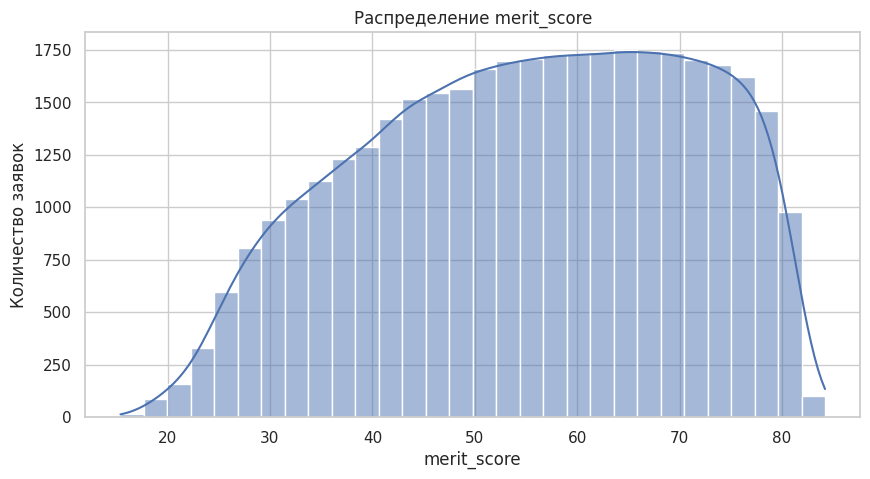

In [38]:
plt.figure(figsize=(10, 5))
sns.histplot(eda_df["merit_score"], bins=30, kde=True)
plt.title("Распределение merit_score")
plt.xlabel("merit_score")
plt.ylabel("Количество заявок")
plt.show()

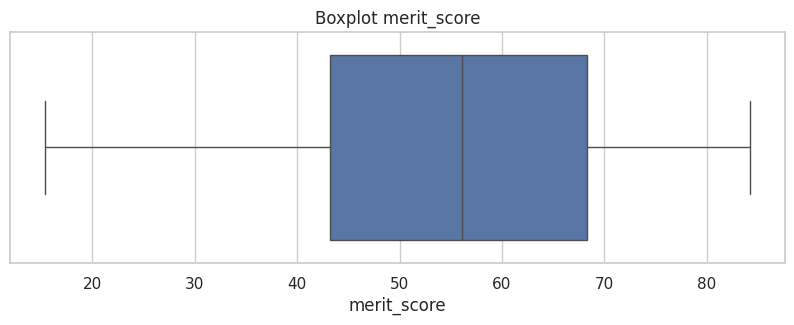

In [39]:
plt.figure(figsize=(10, 3))
sns.boxplot(x=eda_df["merit_score"])
plt.title("Boxplot merit_score")
plt.show()

In [40]:
missing_df = pd.DataFrame({
    "column": eda_df.columns,
    "missing_count": eda_df.isnull().sum().values,
    "missing_pct": (eda_df.isnull().mean().values * 100).round(2)
}).sort_values("missing_pct", ascending=False)

display(missing_df.head(20))

,column,missing_count,missing_pct
0,record_no,0,0.0
1,application_id,0,0.0
2,application_received_at,0,0.0
3,application_date,0,0.0
4,year,0,0.0
5,month,0,0.0
6,quarter,0,0.0
7,day_of_year,0,0.0
8,application_hour,0,0.0
9,region,0,0.0


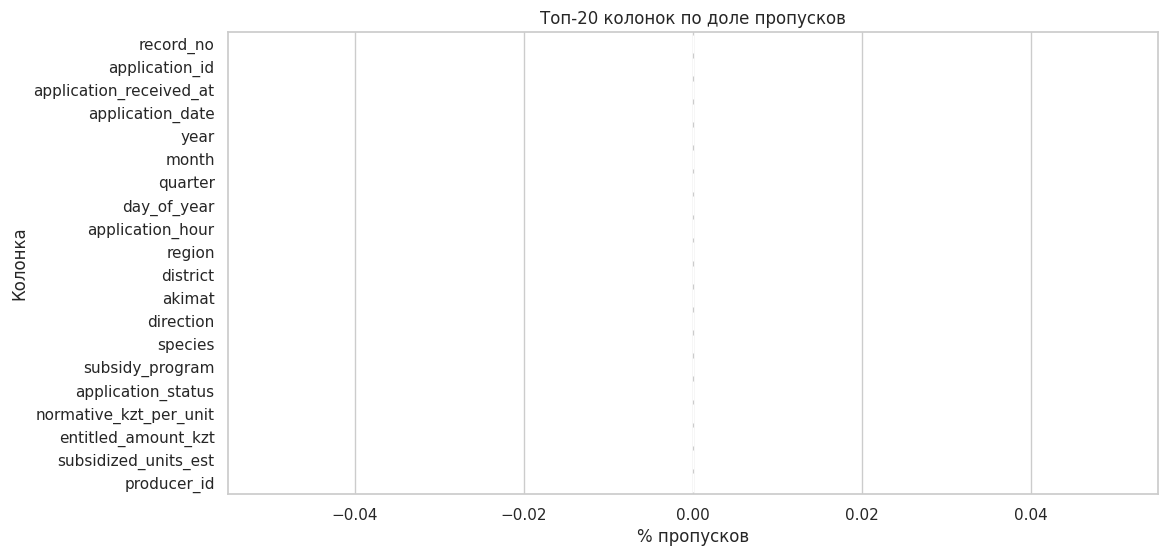

In [41]:
top_missing = missing_df.head(20)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_missing, x="missing_pct", y="column")
plt.title("Топ-20 колонок по доле пропусков")
plt.xlabel("% пропусков")
plt.ylabel("Колонка")
plt.show()

In [42]:
cat_cols_for_review = ["region", "district", "direction", "species", "subsidy_program", "producer_type"]

for col in cat_cols_for_review:
    if col in eda_df.columns:
        print(f"\n===== {col} =====")
        display(eda_df[col].value_counts(dropna=False).head(15))


===== region =====


region
Западно-Казахстанская область     5156
область Абай                      3683
Мангистауская область             3423
Жамбылская область                3312
Алматинская область               2681
Костанайская область              2509
Актюбинская область               2385
Павлодарская область              2281
Туркестанская область             2281
Северо-Казахстанская область      1554
область Жетісу                    1479
Восточно-Казахстанская область    1376
Кызылординская область            1260
Акмолинская область                963
Карагандинская область             926
Name: count, dtype: int64


===== district =====


district
Казталовский район        1450
Сайрамский район          1208
Байзакский район          1164
Енбекшиказахский район    1163
Мангистауский район       1100
район Ақсуат              1028
Бейнеуский район           866
Костанайский район         800
Уйгурский район            702
Семей Г.А.                 695
Жуалынский район           674
Каракиянский район         653
Акжаикский район           639
Жангалинский район         588
Жанакорганский район       569
Name: count, dtype: int64


===== direction =====


...

species
cattle          24397
poultry          5360
sheep            3560
horse            1382
camel            1382
insemination      247
beekeeping        204
swine             116
goat                3
Name: count, dtype: int64


===== subsidy_program =====


subsidy_program
Заявка на получение субсидий за приобретение племенных быков-производителей мясных и мясо-молочных пород                                                                                                                                                                                                                             3935
Заявка на получение субсидий на ведение селекционной и племенной работы с товарным маточным поголовьем крупного рогатого скота                                                                                                                                                                                                       3877
Заявка на получение субсидий на удешевление стоимости крупного рогатого скота (в том числе племенные мужские особи молочных или молочно-мясных пород), реализованных или перемещенных на откорм в откормочные площадки или мясоперерабатывающие предприятия с убойной мощностью не менее 50 голов крупного рогатого скота в сутки   


===== producer_type =====


producer_type
llp                 29960
agroholding_llp      4761
farm_cooperative     1930
Name: count, dtype: int64

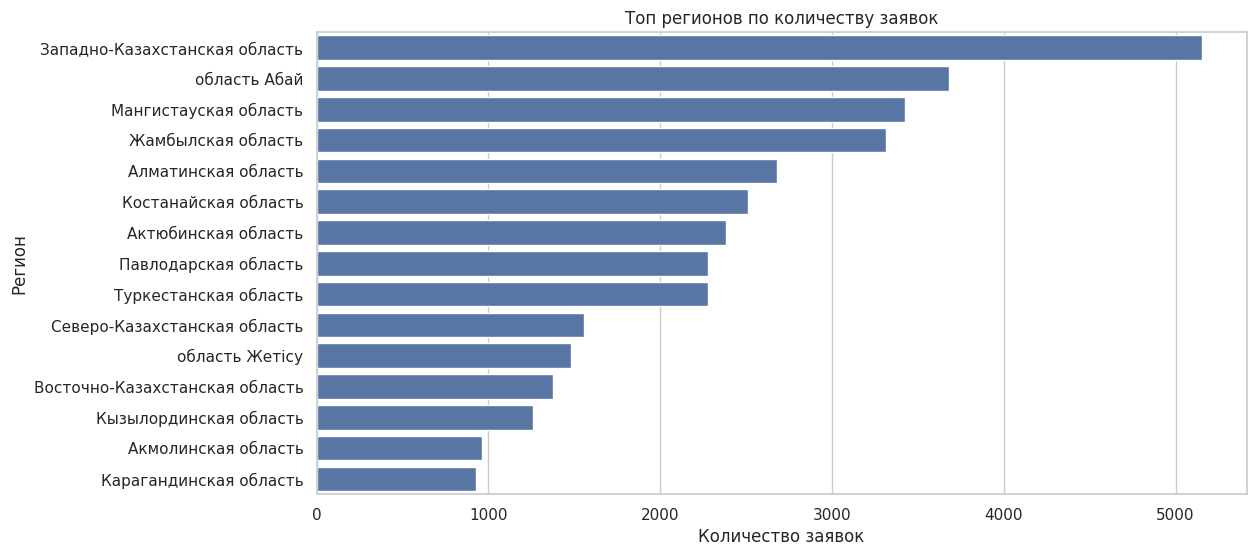

In [43]:
region_counts = eda_df["region"].value_counts().head(15)

plt.figure(figsize=(12, 6))
sns.barplot(x=region_counts.values, y=region_counts.index)
plt.title("Топ регионов по количеству заявок")
plt.xlabel("Количество заявок")
plt.ylabel("Регион")
plt.show()

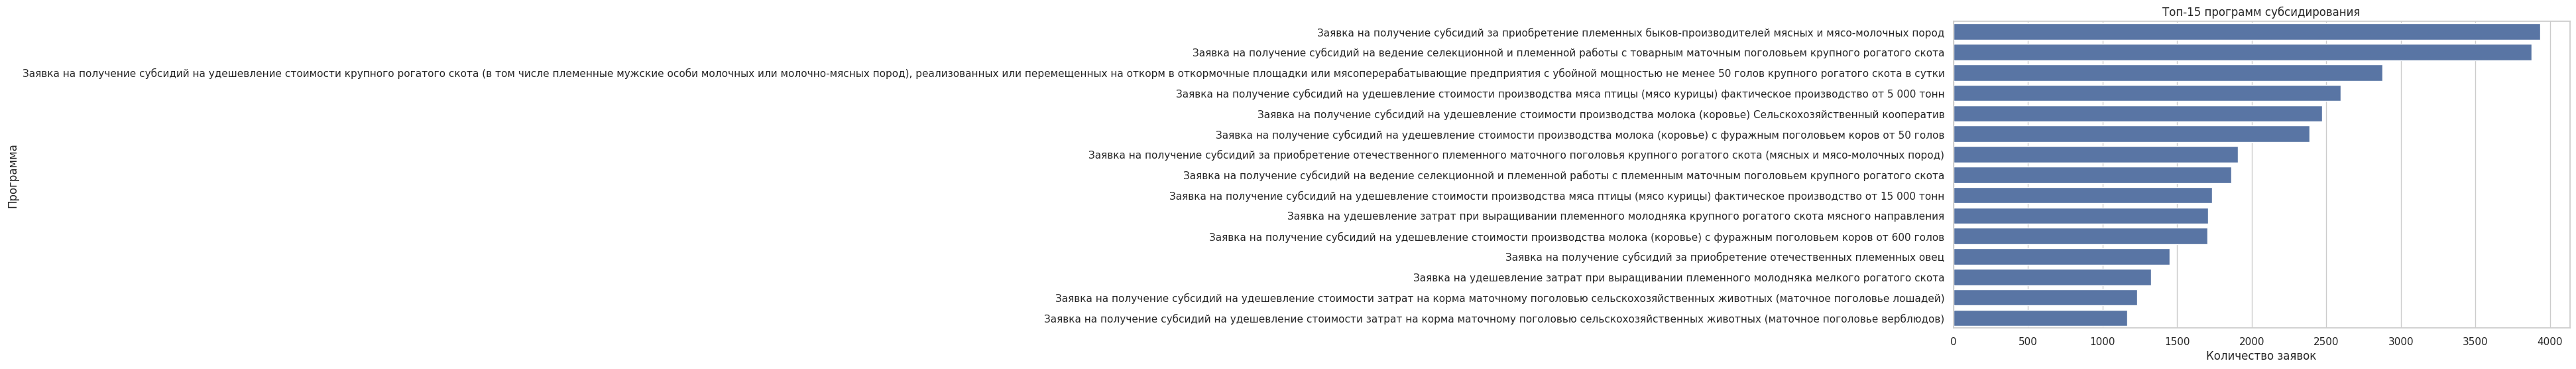

In [44]:
top_programs = eda_df["subsidy_program"].value_counts().head(15)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_programs.values, y=top_programs.index)
plt.title("Топ-15 программ субсидирования")
plt.xlabel("Количество заявок")
plt.ylabel("Программа")
plt.show()

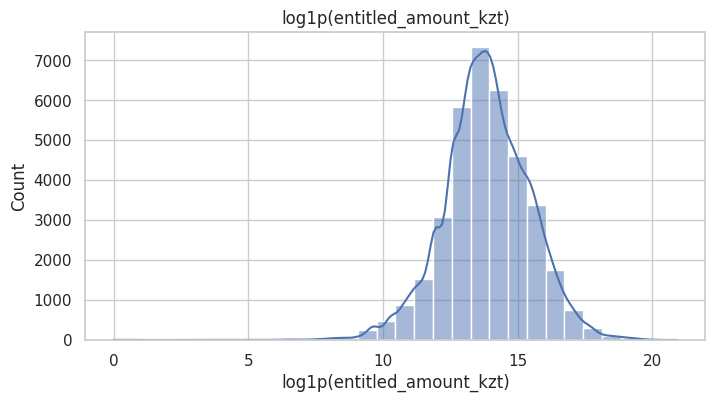

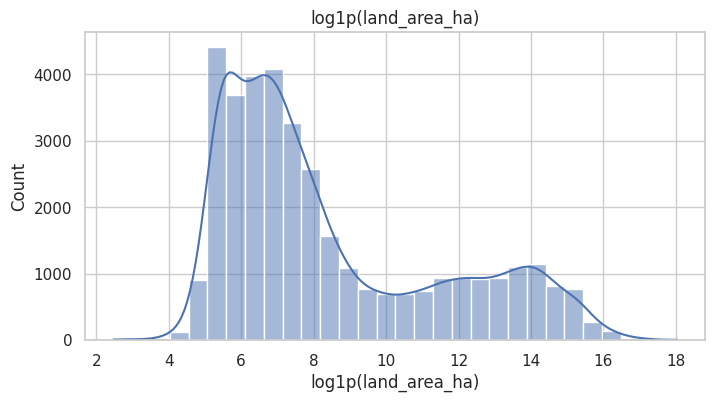

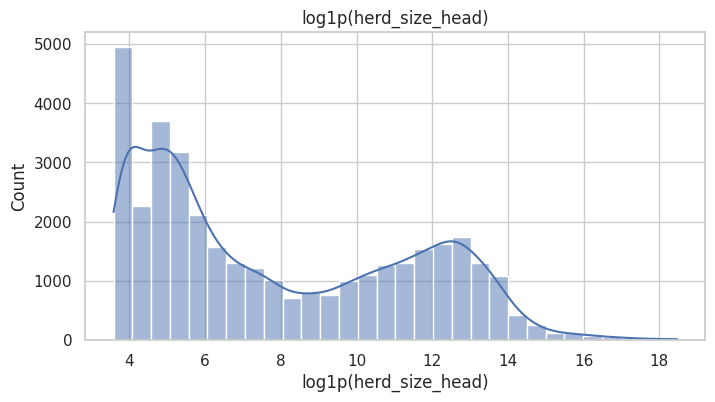

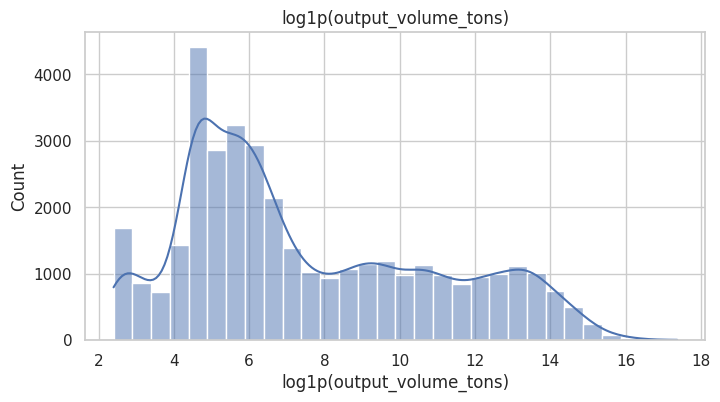

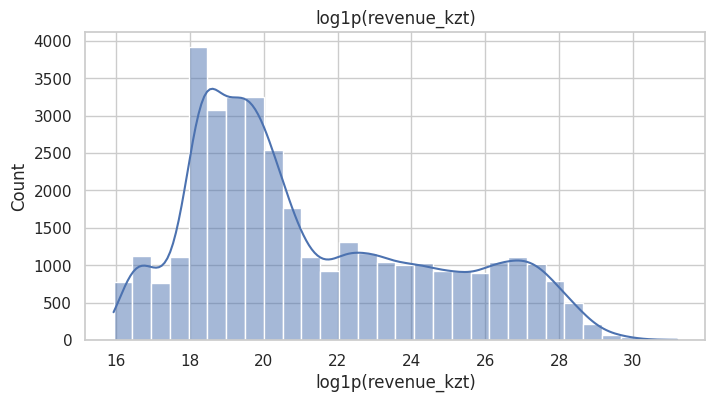

In [45]:
log_cols = ["entitled_amount_kzt", "land_area_ha", "herd_size_head", "output_volume_tons", "revenue_kzt"]

for col in log_cols:
    if col in eda_df.columns:
        plt.figure(figsize=(8, 4))
        sns.histplot(np.log1p(eda_df[col]), bins=30, kde=True)
        plt.title(f"log1p({col})")
        plt.xlabel(f"log1p({col})")
        plt.show()

In [46]:
eda_df["merit_group"] = pd.qcut(
    eda_df["merit_score"],
    q=5,
    labels=["Very Low", "Low", "Medium", "High", "Very High"]
)

eda_df[["merit_score", "merit_group"]].head()

,merit_score,merit_group
0,59.2,Medium
1,67.9,High
2,51.1,Low
3,59.3,Medium
4,54.5,Medium


In [47]:
eda_df = df.copy()

In [48]:
outlier_cols = [
    "entitled_amount_kzt",
    "land_area_ha",
    "herd_size_head",
    "output_volume_tons",
    "revenue_kzt",
    "productivity_index",
    "past_paid_amount_kzt"
]

rows = []

for col in outlier_cols:
    q1 = eda_df[col].quantile(0.25)
    q3 = eda_df[col].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers_count = ((eda_df[col] < lower_bound) | (eda_df[col] > upper_bound)).sum()
    outliers_pct = round(outliers_count / len(eda_df) * 100, 2)

    rows.append([
        col,
        q1,
        q3,
        iqr,
        lower_bound,
        upper_bound,
        outliers_count,
        outliers_pct
    ])

outlier_df = pd.DataFrame(rows, columns=[
    "column",
    "q1",
    "q3",
    "iqr",
    "lower_bound",
    "upper_bound",
    "outliers_count",
    "outliers_pct"
])

outlier_df = outlier_df.sort_values("outliers_pct", ascending=False)
outlier_df

,column,q1,q3,iqr,lower_bound,upper_bound,outliers_count,outliers_pct
1,land_area_ha,446.1,3.551290e+04,3.506680e+04,-5.215410e+04,8.811310e+04,7860,21.45
4,revenue_kzt,133121517.0,2.038551e+10,2.025239e+10,-3.024547e+10,5.076410e+10,7381,20.14
3,output_volume_tons,133.5,2.462625e+04,2.449275e+04,-3.660562e+04,6.136538e+04,7236,19.74
2,herd_size_head,122.0,7.545500e+04,7.533300e+04,-1.128775e+05,1.884545e+05,6508,17.76
6,past_paid_amount_kzt,0.0,3.948090e+06,3.948090e+06,-5.922135e+06,9.870225e+06,5011,13.67
0,entitled_amount_kzt,403430.0,2.995320e+06,2.591890e+06,-3.484405e+06,6.883155e+06,4195,11.45
5,productivity_index,103.4,1.181000e+02,1.470000e+01,8.135000e+01,1.401500e+02,887,2.42


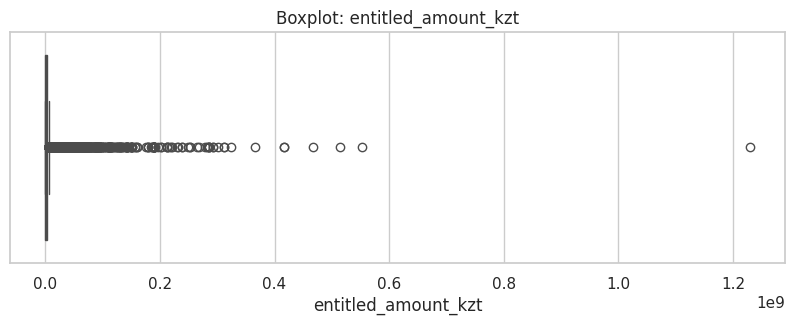

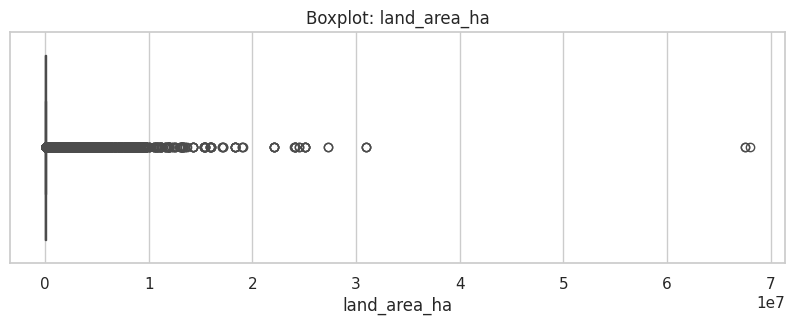

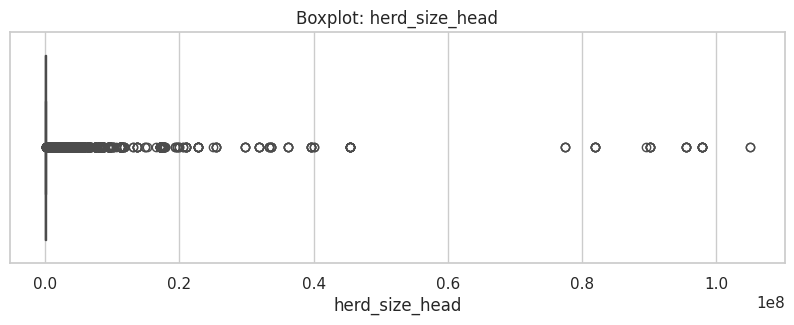

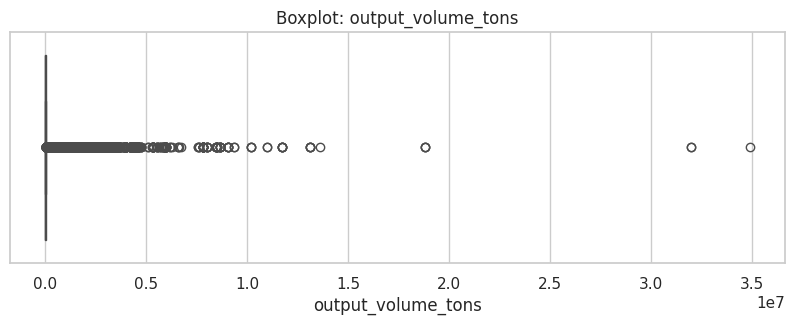

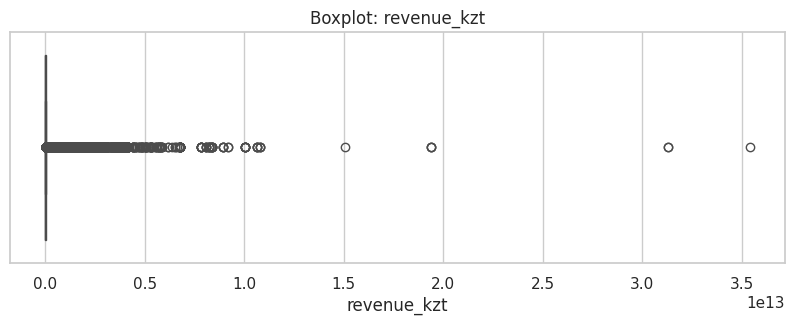

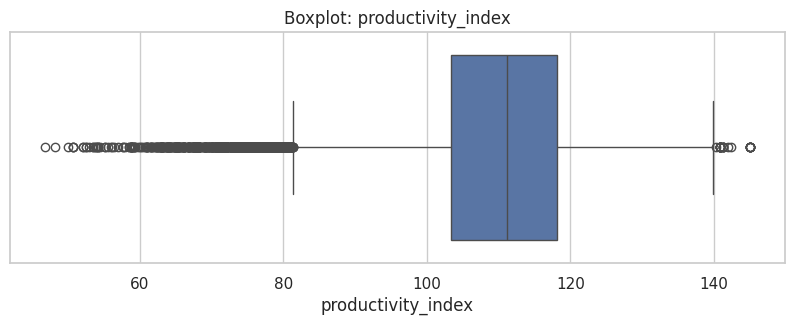

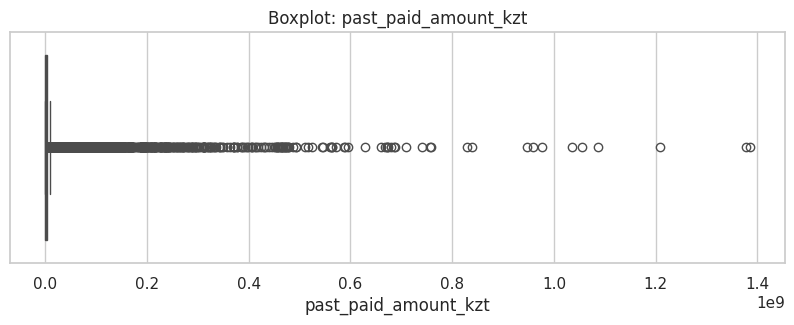

In [49]:
for col in outlier_cols:
    plt.figure(figsize=(10, 3))
    sns.boxplot(x=eda_df[col])
    plt.title(f"Boxplot: {col}")
    plt.show()

In [50]:
q20 = eda_df["merit_score"].quantile(0.2)
q80 = eda_df["merit_score"].quantile(0.8)

bottom_df = eda_df[eda_df["merit_score"] <= q20].copy()
top_df = eda_df[eda_df["merit_score"] >= q80].copy()

print("Bottom 20%:", bottom_df.shape)
print("Top 20%:", top_df.shape)

Bottom 20%: (7371, 61)
Top 20%: (7380, 61)


In [51]:
comparison = pd.DataFrame({
    "feature": [
        "land_area_ha",
        "herd_size_head",
        "output_volume_tons",
        "productivity_index",
        "revenue_kzt",
        "prior_subsidies_count_3y",
        "prior_violations_count_3y",
        "past_paid_amount_kzt"
    ],
    "bottom_20_mean": [
        bottom_df["land_area_ha"].mean(),
        bottom_df["herd_size_head"].mean(),
        bottom_df["output_volume_tons"].mean(),
        bottom_df["productivity_index"].mean(),
        bottom_df["revenue_kzt"].mean(),
        bottom_df["prior_subsidies_count_3y"].mean(),
        bottom_df["prior_violations_count_3y"].mean(),
        bottom_df["past_paid_amount_kzt"].mean()
    ],
    "top_20_mean": [
        top_df["land_area_ha"].mean(),
        top_df["herd_size_head"].mean(),
        top_df["output_volume_tons"].mean(),
        top_df["productivity_index"].mean(),
        top_df["revenue_kzt"].mean(),
        top_df["prior_subsidies_count_3y"].mean(),
        top_df["prior_violations_count_3y"].mean(),
        top_df["past_paid_amount_kzt"].mean()
    ]
})

comparison["difference"] = comparison["top_20_mean"] - comparison["bottom_20_mean"]
comparison

,feature,bottom_20_mean,top_20_mean,difference
0,land_area_ha,3.604605e+05,2.903360e+05,-7.012458e+04
1,herd_size_head,2.293394e+05,2.975353e+05,6.819594e+04
2,output_volume_tons,1.431780e+05,1.472229e+05,4.044985e+03
3,productivity_index,9.631069e+01,1.218582e+02,2.554752e+01
4,revenue_kzt,1.348998e+11,1.375349e+11,2.635126e+09
5,prior_subsidies_count_3y,7.449600e+00,8.630081e+00,1.180482e+00
6,prior_violations_count_3y,1.328856e+00,4.457995e-02,-1.284276e+00
7,past_paid_amount_kzt,4.299881e+06,9.723991e+06,5.424110e+06


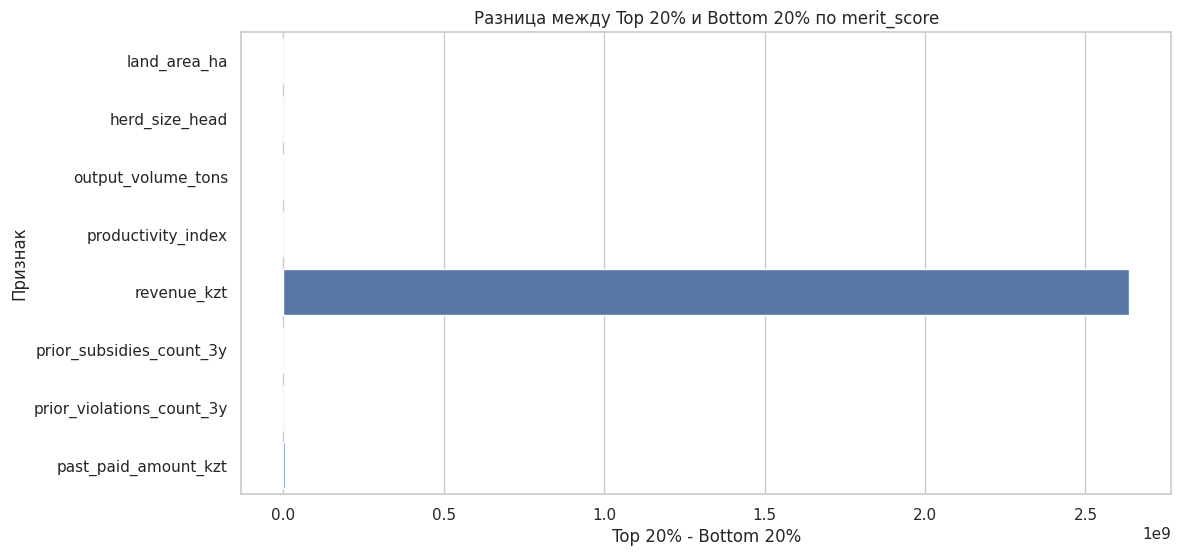

In [52]:
plt.figure(figsize=(12, 6))
sns.barplot(data=comparison, x="difference", y="feature")
plt.title("Разница между Top 20% и Bottom 20% по merit_score")
plt.xlabel("Top 20% - Bottom 20%")
plt.ylabel("Признак")
plt.show()

In [53]:
producer_level = (
    eda_df.groupby("producer_id")
    .agg({
        "application_id": "count",
        "merit_score": ["mean", "median"],
        "revenue_kzt": "mean",
        "productivity_index": "mean",
        "output_volume_tons": "mean",
        "past_paid_amount_kzt": "max",
        "prior_subsidies_count_3y": "max",
        "prior_violations_count_3y": "max",
        "producer_type": "first",
        "region": "first"
    })
)

producer_level.columns = [
    "applications_count",
    "avg_merit_score",
    "median_merit_score",
    "avg_revenue_kzt",
    "avg_productivity_index",
    "avg_output_volume_tons",
    "past_paid_amount_kzt",
    "prior_subsidies_count_3y",
    "prior_violations_count_3y",
    "producer_type",
    "region"
]

producer_level = producer_level.reset_index()
producer_level.head()

,producer_id,applications_count,avg_merit_score,median_merit_score,avg_revenue_kzt,avg_productivity_index,avg_output_volume_tons,past_paid_amount_kzt,prior_subsidies_count_3y,prior_violations_count_3y,producer_type,region
0,PRD_000001,1,59.200000,59.2,8.499157e+08,125.1,876.1,0.0,2,1,llp,Акмолинская область
1,PRD_000002,1,67.900000,67.9,8.039290e+07,116.6,91.9,0.0,6,0,llp,Акмолинская область
2,PRD_000004,3,54.966667,54.5,1.404313e+11,101.7,147551.2,1700780.0,7,0,llp,Акмолинская область
3,PRD_000005,2,22.800000,22.8,1.157502e+11,104.5,163377.5,0.0,6,5,llp,Акмолинская область
4,PRD_000006,2,26.100000,26.1,1.425211e+11,84.4,163301.6,0.0,5,2,llp,Акмолинская область


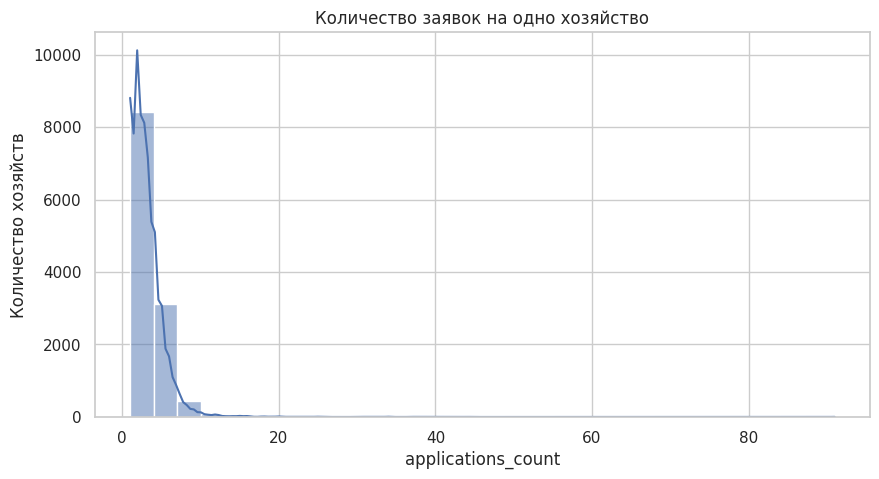

In [54]:
plt.figure(figsize=(10, 5))
sns.histplot(producer_level["applications_count"], bins=30, kde=True)
plt.title("Количество заявок на одно хозяйство")
plt.xlabel("applications_count")
plt.ylabel("Количество хозяйств")
plt.show()

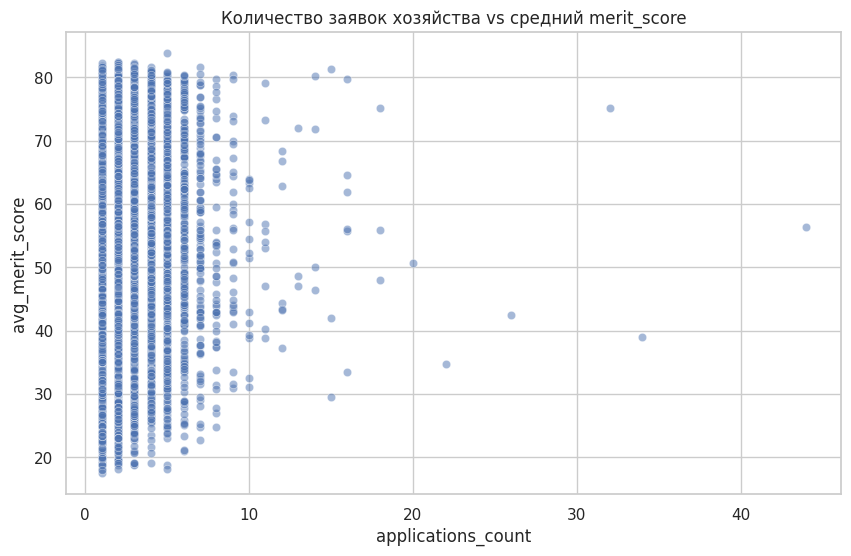

In [55]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=producer_level.sample(min(5000, len(producer_level)), random_state=42),
    x="applications_count",
    y="avg_merit_score",
    alpha=0.5
)
plt.title("Количество заявок хозяйства vs средний merit_score")
plt.xlabel("applications_count")
plt.ylabel("avg_merit_score")
plt.show()

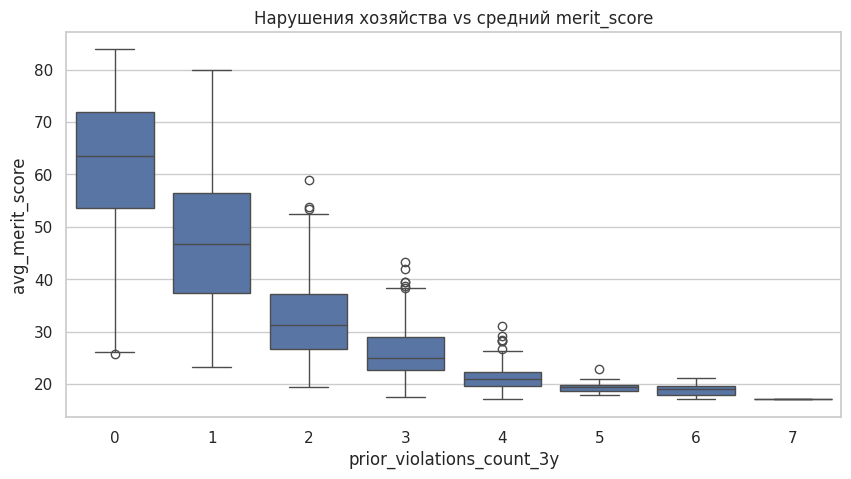

In [56]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=producer_level, x="prior_violations_count_3y", y="avg_merit_score")
plt.title("Нарушения хозяйства vs средний merit_score")
plt.xlabel("prior_violations_count_3y")
plt.ylabel("avg_merit_score")
plt.show()

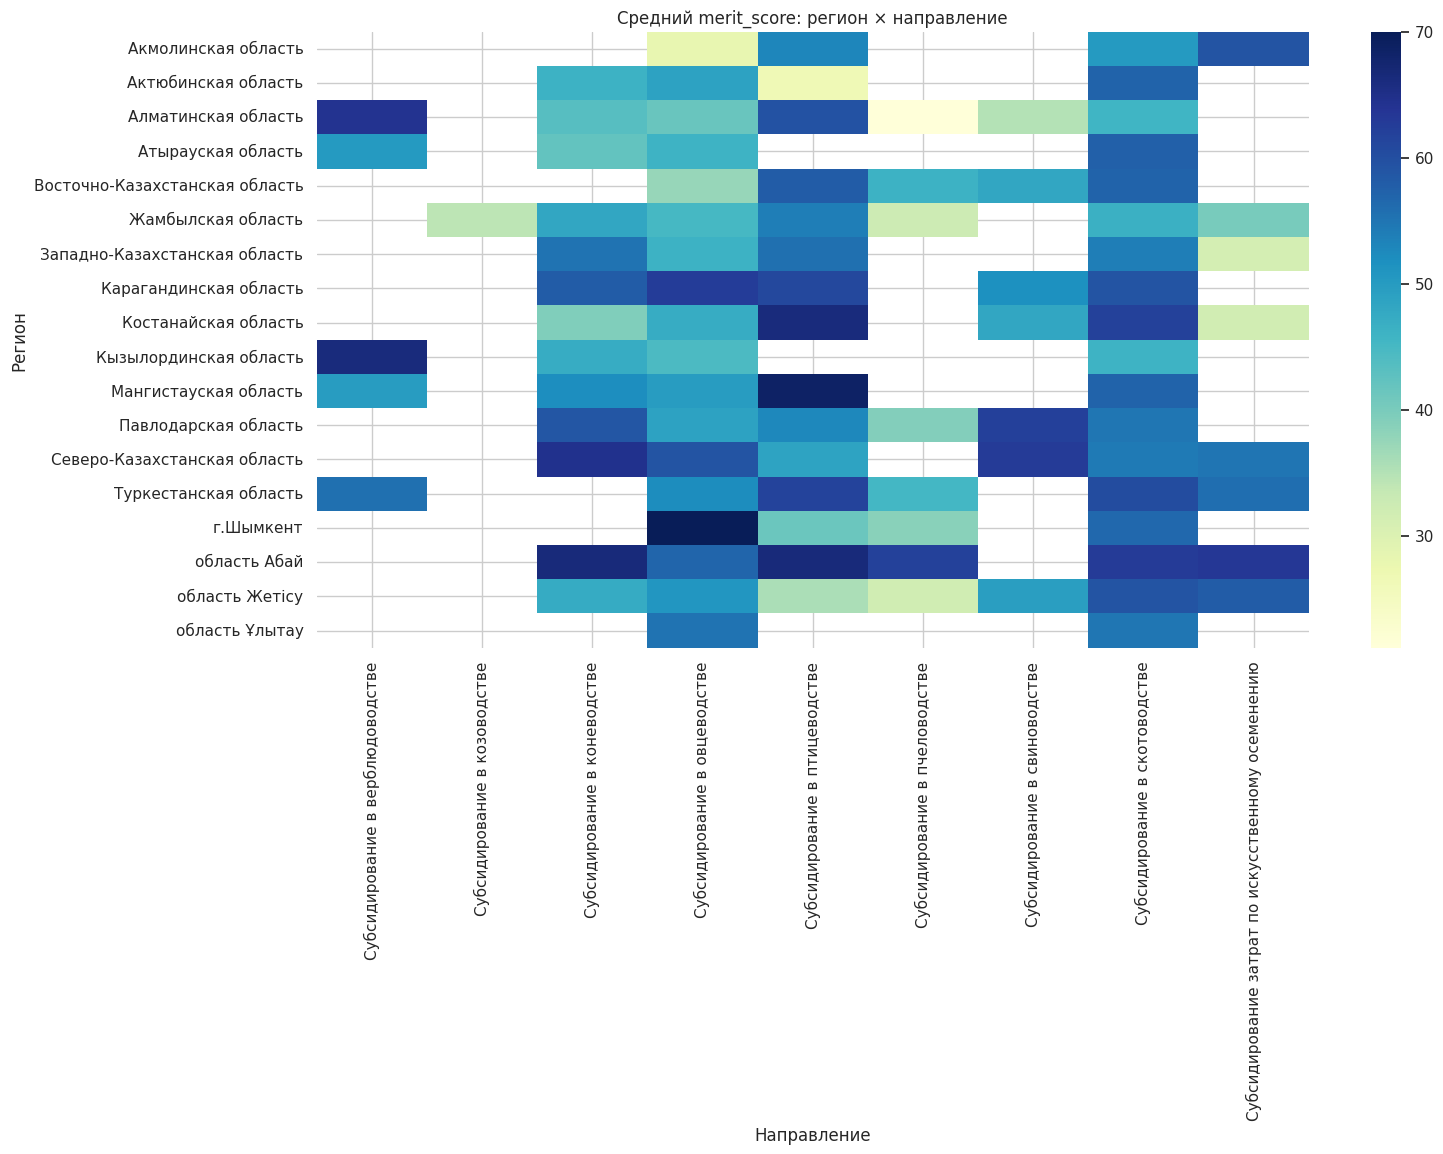

In [57]:
region_direction_pivot = pd.pivot_table(
    eda_df,
    values="merit_score",
    index="region",
    columns="direction",
    aggfunc="mean"
)

plt.figure(figsize=(16, 8))
sns.heatmap(region_direction_pivot, cmap="YlGnBu", annot=False)
plt.title("Средний merit_score: регион × направление")
plt.xlabel("Направление")
plt.ylabel("Регион")
plt.show()

In [59]:
candles_df = eda_df.dropna(subset=["application_date", "merit_score"]).copy()
candles_df = candles_df.sort_values("application_date")

ohlc_merit = (
    candles_df
    .set_index("application_date")["merit_score"]
    .resample("ME")
    .agg(["first", "max", "min", "last"])
    .dropna()
    .reset_index()
)

ohlc_merit.columns = ["date", "open", "high", "low", "close"]
ohlc_merit

TypeError: Only valid with DatetimeIndex, TimedeltaIndex or PeriodIndex, but got an instance of 'Index'

In [60]:
print(eda_df["application_date"].dtype)
eda_df["application_date"].head(10)

str


0    2025-12-19
1    2025-05-06
2    2025-03-06
3    2025-06-02
4    2025-12-11
5    2025-05-30
6    2025-10-07
7    2025-09-11
8    2025-11-11
9    2025-11-06
Name: application_date, dtype: str

In [61]:
eda_df["application_date"] = pd.to_datetime(eda_df["application_date"], errors="coerce")
print(eda_df["application_date"].dtype)

datetime64[us]


In [62]:
print("Пропусков в application_date:", eda_df["application_date"].isna().sum())
eda_df[eda_df["application_date"].isna()].head()

Пропусков в application_date: 0


,record_no,application_id,application_received_at,application_date,year,month,quarter,day_of_year,application_hour,region,district,akimat,direction,species,subsidy_program,application_status,normative_kzt_per_unit,entitled_amount_kzt,subsidized_units_est,producer_id,producer_type,years_in_operation,employees_count,land_area_ha,herd_size_head,output_volume_tons,productivity_index,revenue_kzt,ebitda_margin_pct,debt_to_revenue_pct,prior_subsidies_count_3y,prior_subsidies_amount_kzt_3y,prior_violations_count_3y,prior_refunds_count_3y,prior_refunds_amount_kzt_3y,unmet_obligations_flag,prior_avg_output_growth_pct,prior_avg_revenue_growth_pct,producer_application_seq_no,past_applications_count,past_approved_count,past_rejected_count,past_withdrawn_count,past_paid_amount_kzt,past_avg_entitled_amount_kzt,region_execution_rate_real,district_execution_rate_real,direction_execution_rate_real,program_execution_rate_real,need_score,impact_score,compliance_score,merit_score,shortlist_bucket,merit_recommended_flag,post_effect_output_growth_pct,post_effect_revenue_growth_pct,post_effect_productivity_growth_pct,post_effect_compliance_flag,outcome_effective_flag,data_origin


In [63]:
candles_df = eda_df[["application_date", "merit_score"]].copy()
candles_df["application_date"] = pd.to_datetime(candles_df["application_date"], errors="coerce")
candles_df = candles_df.dropna(subset=["application_date", "merit_score"])
candles_df = candles_df.sort_values("application_date")

print(candles_df["application_date"].dtype)
candles_df.head()

datetime64[us]


,application_date,merit_score
25395,2025-01-21,41.6
33595,2025-01-21,42.8
821,2025-01-21,48.2
33673,2025-01-21,31.1
33872,2025-01-21,60.2


In [64]:
ohlc_merit = (
    candles_df
    .set_index("application_date")["merit_score"]
    .resample("ME")
    .agg(["first", "max", "min", "last"])
    .dropna()
    .reset_index()
)

ohlc_merit.columns = ["date", "open", "high", "low", "close"]
ohlc_merit.head()

,date,open,high,low,close
0,2025-01-31,41.6,81.9,21.6,27.0
1,2025-02-28,46.5,82.0,18.5,56.0
2,2025-03-31,77.5,82.4,15.4,54.9
3,2025-04-30,80.0,82.9,19.8,51.2
4,2025-05-31,46.1,84.1,18.0,73.2


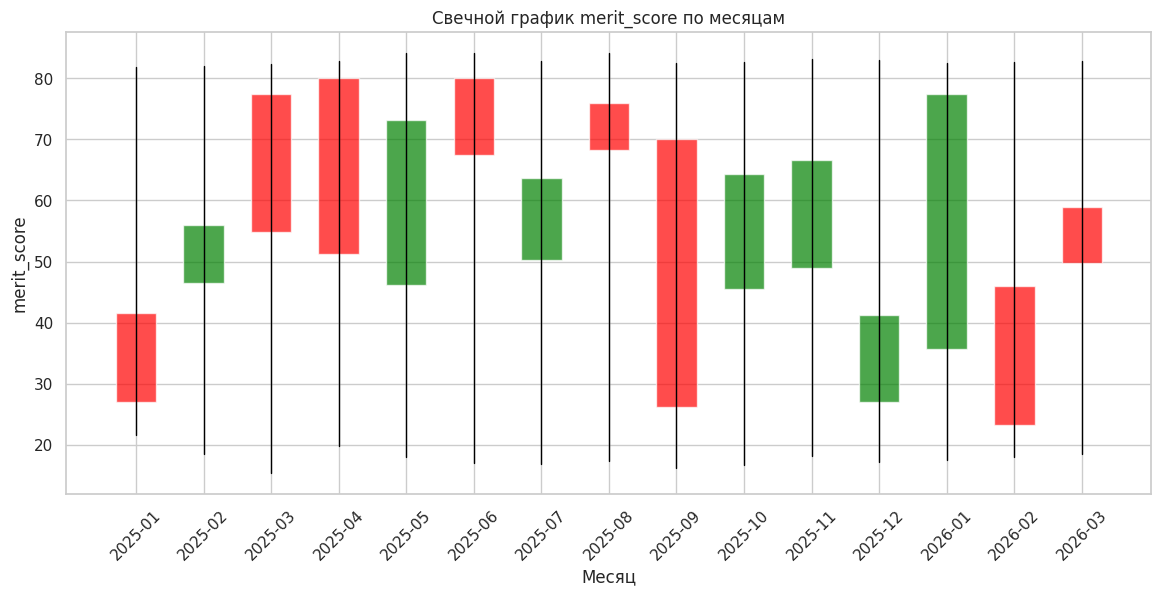

In [65]:
plt.figure(figsize=(14, 6))

for i, row in ohlc_merit.iterrows():
    color = "green" if row["close"] >= row["open"] else "red"

    plt.plot([i, i], [row["low"], row["high"]], color="black", linewidth=1)

    lower = min(row["open"], row["close"])
    height = abs(row["close"] - row["open"])

    plt.bar(
        i,
        height if height > 0 else 0.1,
        bottom=lower,
        width=0.6,
        color=color,
        alpha=0.7
    )

plt.xticks(range(len(ohlc_merit)), ohlc_merit["date"].dt.strftime("%Y-%m"), rotation=45)
plt.title("Свечной график merit_score по месяцам")
plt.xlabel("Месяц")
plt.ylabel("merit_score")
plt.show()

In [66]:
temp = candles_df.set_index("application_date")
print(type(temp.index))

<class 'pandas.DatetimeIndex'>


In [68]:
!pip install catboost
!pip install sklearn

  Using cached scipy-1.17.1-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (62 kB)
  Using cached narwhals-2.18.1-py3-none-any.whl.metadata (14 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 15.5 MB/s  0:00:06m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 12.4 MB/s  0:00:00 eta 0:00:01
Using cached narwhals-2.18.1-py3-none-any.whl (444 kB)
Using cached scipy-1.17.1-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (35.2 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [catboost]4/5 [catboost]
  Using cached sklearn-0.0.post12.tar.gz (2.6 kB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... error
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [15 lines of output]
      The 'sklearn' PyPI package is deprecated, use 'scikit-learn'
      rather than 'sklearn' for pip commands.
      
      Here is how to 

In [70]:
!pip install scikit-learn

  Using cached scikit_learn-1.8.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (11 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.8.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (8.9 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [scikit-learn] [scikit-learn]


In [71]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

train_idx, test_idx = next(gss.split(X, y, groups=group_col))

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()

y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

groups_train = group_col.iloc[train_idx].copy()
groups_test = group_col.iloc[test_idx].copy()

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(29306, 52) (7345, 52) (29306,) (7345,)


In [72]:
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

In [73]:
categorical_cols = X_train.select_dtypes(include=["object", "category", "bool", "string"]).columns.tolist()
numeric_cols = X_train.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns.tolist()

print("Категориальные:", len(categorical_cols))
print(categorical_cols)

print("\nЧисловые:", len(numeric_cols))
print(numeric_cols)

Категориальные: 8
['region', 'district', 'akimat', 'direction', 'species', 'subsidy_program', 'producer_type', 'data_origin']

Числовые: 44
['record_no', 'year', 'month', 'quarter', 'day_of_year', 'application_hour', 'normative_kzt_per_unit', 'entitled_amount_kzt', 'subsidized_units_est', 'years_in_operation', 'employees_count', 'land_area_ha', 'herd_size_head', 'output_volume_tons', 'productivity_index', 'revenue_kzt', 'ebitda_margin_pct', 'debt_to_revenue_pct', 'prior_subsidies_count_3y', 'prior_subsidies_amount_kzt_3y', 'prior_violations_count_3y', 'prior_refunds_count_3y', 'prior_refunds_amount_kzt_3y', 'unmet_obligations_flag', 'prior_avg_output_growth_pct', 'prior_avg_revenue_growth_pct', 'producer_application_seq_no', 'past_applications_count', 'past_approved_count', 'past_rejected_count', 'past_withdrawn_count', 'past_paid_amount_kzt', 'past_avg_entitled_amount_kzt', 'region_execution_rate_real', 'district_execution_rate_real', 'direction_execution_rate_real', 'program_executio

In [74]:
model = CatBoostRegressor(
    iterations=700,
    learning_rate=0.05,
    depth=6,
    loss_function="RMSE",
    eval_metric="RMSE",
    random_seed=42,
    verbose=100
)

model.fit(
    X_train,
    y_train,
    cat_features=categorical_cols,
    eval_set=(X_test, y_test),
    use_best_model=True
)

0:	learn: 14.8443252	test: 15.1478220	best: 15.1478220 (0)	total: 63.4ms	remaining: 44.3s
100:	learn: 2.5721087	test: 2.6095707	best: 2.6095707 (100)	total: 2.05s	remaining: 12.2s
200:	learn: 1.9875428	test: 2.0277756	best: 2.0277756 (200)	total: 4.18s	remaining: 10.4s
300:	learn: 1.7446438	test: 1.8094475	best: 1.8094475 (300)	total: 6.02s	remaining: 7.98s
400:	learn: 1.6157840	test: 1.7069498	best: 1.7069498 (400)	total: 7.95s	remaining: 5.93s
500:	learn: 1.5332981	test: 1.6466940	best: 1.6466940 (500)	total: 9.63s	remaining: 3.83s
600:	learn: 1.4700969	test: 1.6017717	best: 1.6017717 (600)	total: 11.3s	remaining: 1.86s
699:	learn: 1.4260100	test: 1.5720556	best: 1.5720556 (699)	total: 13.3s	remaining: 0us

bestTest = 1.57205557
bestIteration = 699



CatBoostRegressor(depth=6, eval_metric='RMSE', iterations=700, learning_rate=0.05, loss_function='RMSE', random_seed=42, verbose=100)

In [75]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[62.47972924 26.80577276 22.99427562 56.01078247 60.58501616 61.43509665
 61.80136632 63.74048837 60.86523207 33.00182233]


In [76]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", round(mae, 4))
print("RMSE:", round(rmse, 4))
print("R2:", round(r2, 4))

MAE: 1.1009
RMSE: 1.5721
R2: 0.9901


In [77]:
pred_df = pd.DataFrame({
    "actual": y_test.values,
    "predicted": y_pred
})

pred_df.head()

,actual,predicted
0,59.2,62.479729
1,23.6,26.805773
2,22.0,22.994276
3,55.3,56.010782
4,60.6,60.585016


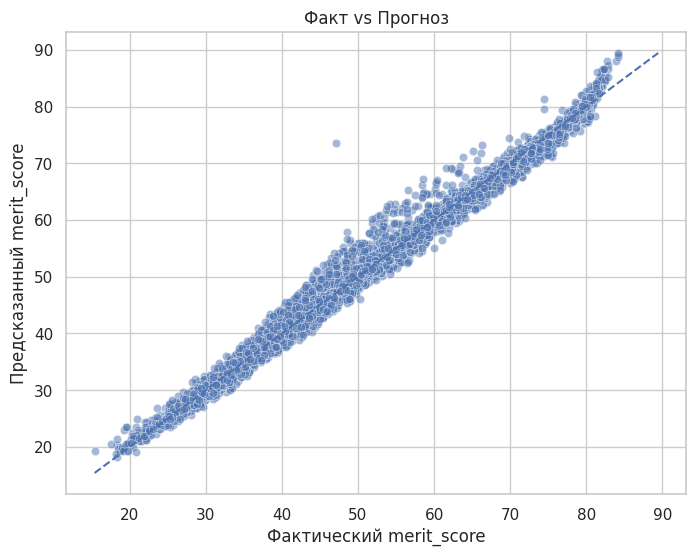

In [78]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=pred_df, x="actual", y="predicted", alpha=0.5)

min_val = min(pred_df["actual"].min(), pred_df["predicted"].min())
max_val = max(pred_df["actual"].max(), pred_df["predicted"].max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.title("Факт vs Прогноз")
plt.xlabel("Фактический merit_score")
plt.ylabel("Предсказанный merit_score")
plt.show()

In [79]:
pred_df["error"] = pred_df["actual"] - pred_df["predicted"]
pred_df["abs_error"] = np.abs(pred_df["error"])

pred_df.head()

,actual,predicted,error,abs_error
0,59.2,62.479729,-3.279729,3.279729
1,23.6,26.805773,-3.205773,3.205773
2,22.0,22.994276,-0.994276,0.994276
3,55.3,56.010782,-0.710782,0.710782
4,60.6,60.585016,0.014984,0.014984


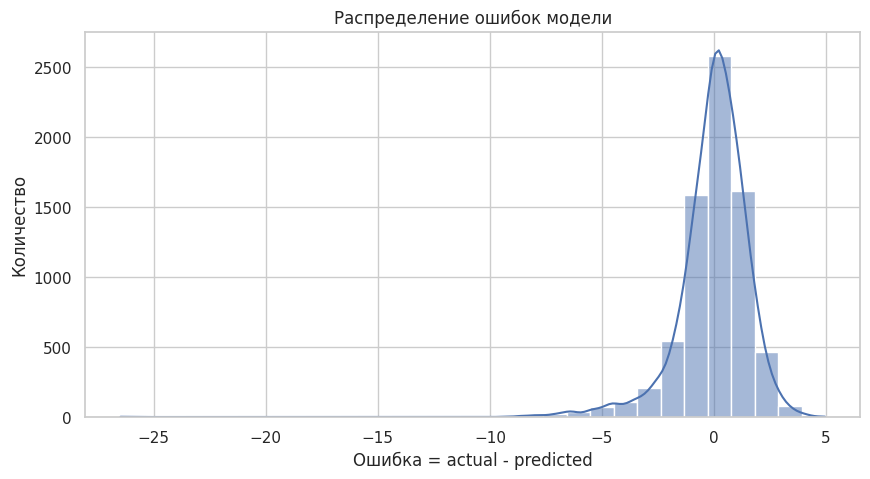

In [80]:
plt.figure(figsize=(10, 5))
sns.histplot(pred_df["error"], bins=30, kde=True)
plt.title("Распределение ошибок модели")
plt.xlabel("Ошибка = actual - predicted")
plt.ylabel("Количество")
plt.show()

In [81]:
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model.get_feature_importance()
})

feature_importance = feature_importance.sort_values("importance", ascending=False)
feature_importance.head(20)

,feature,importance
21,productivity_index,38.068725
30,unmet_obligations_flag,16.969425
27,prior_violations_count_3y,11.187852
31,prior_avg_output_growth_pct,4.475339
13,entitled_amount_kzt,3.307102
29,prior_refunds_amount_kzt_3y,2.960173
26,prior_subsidies_amount_kzt_3y,2.546301
15,producer_type,2.346838
32,prior_avg_revenue_growth_pct,2.128299
23,ebitda_margin_pct,1.589292


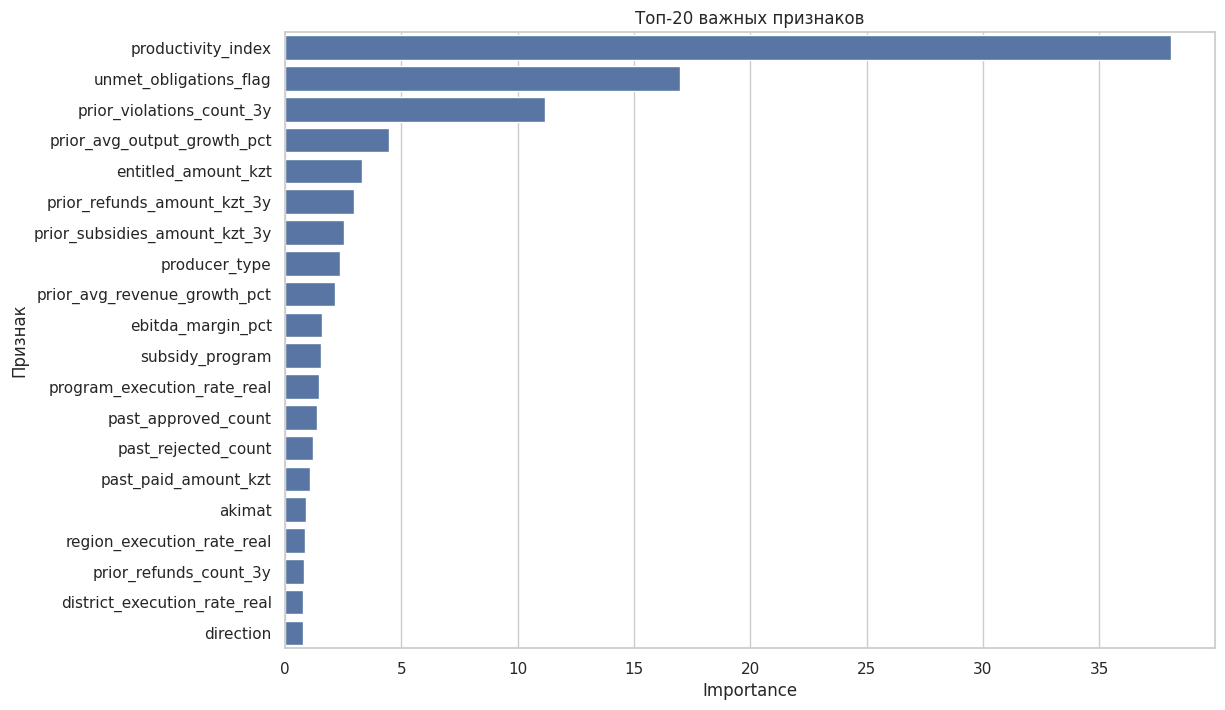

In [82]:
top_features = feature_importance.head(20)

plt.figure(figsize=(12, 8))
sns.barplot(data=top_features, x="importance", y="feature")
plt.title("Топ-20 важных признаков")
plt.xlabel("Importance")
plt.ylabel("Признак")
plt.show()

In [83]:
model.save_model("catboost_merit_model.cbm")

In [84]:
pred_df.to_csv("test_predictions.csv", index=False)
feature_importance.to_csv("feature_importance.csv", index=False)

In [85]:
import joblib
import pandas as pd

model.save_model("catboost_merit_model.cbm")

joblib.dump(X_train.columns.tolist(), "model_columns.pkl")
joblib.dump(categorical_cols, "categorical_cols.pkl")

default_values = {}
for col in X_train.columns:
    if col in categorical_cols:
        mode_vals = X_train[col].mode(dropna=True)
        default_values[col] = str(mode_vals.iloc[0]) if len(mode_vals) > 0 else "Unknown"
    else:
        default_values[col] = float(X_train[col].median())

joblib.dump(default_values, "default_values.pkl")

category_options = {}
for col in categorical_cols:
    vals = X_train[col].dropna().astype(str).unique().tolist()
    category_options[col] = sorted(vals)

joblib.dump(category_options, "category_options.pkl")

print("Сохранено")

Сохранено
